# Proyecto 1 - Parte 1

## Pedro Pablo Sanín Trujillo - 202221527


## Parte 1 - Importación de librerías y preprocesamiento de los textos.

Primero explicaremos el funcionamiento del procesamiento en un documento individual y luego construiremos el pipeline para aplicar las transformaciones al conjunto de datos. Inicialmente, haremos el preprocesamiento de los textos del conjunto de entrenamiento. Luego, tokenizaremos el texto para dividirlo en palabras individuales. Finalmente, hacemos stemming para que las palabras con la misma raíz sean consideradas como la misma palabra. Note que, en general, no nos interesan las terminaciones de las palabras. Por ejemplo, en el contexto del problema, las palabras: compra, compras y compramos nos transmiten básicamente la misma información. Tomar estas palabras como diferentes hace que los modelos sean innecesariamente pesados y complicados.

- Tokenización: Usaremos `word_tokenize` de `NLTK`.
- Stemming: Usaremos `SnowballStemmer` de `NLTK` con el idioma fijado en `spanish`.


In [1]:
# Importación de librerías
import nltk
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample

nltk.download(
    "punkt_tab"
)  # Descargamos el tokenizador de NLTK para poder usar word_tokenize
nltk.download(
    "stopwords"
)  # Descargamos las stopwords de NLTK para poder filtrar palabras comunes

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv("data/train.csv")

data = df.copy(deep=True)

print(f"Documentos cargados: {len(data)}")
data.head()

Documentos cargados: 12000


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [3]:
data.describe(include=["object"])

/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_87943/2389127942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["object"])


,text,label
count,12000,12000
unique,12000,3
top,Lo pedí un martes por la noche y me llegó al d...,positivo
freq,1,4212


In [4]:
data["label"].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

Vemos que en este caso, no tenemos datos faltantes inválidos, además, el número de datos de cada categoría es mas o menos igual. Por lo que podemos proceder directamente a la tokenización y stemming.


Luego identificamos las `stop words` en español presentes en el texto. Estas son palabras que no agregan significado al texto, como y, de, un, entre otras.

Para procesar estas palabras, usamos `stopwords` de `nltk.corpus` Al final, construimos una función `tokenizer_stemmer` para aplicar la tokenización, stemming y eliminación de stopwords.

Asimismo, revisamos el conjunto de stopwords y eliminamos aquellas que expresen algo negativo, pues estas nos ayudan a clasificar correctamente los mensajes.


In [5]:
spanish_stopwords_completas = set(stopwords.words("spanish"))

palabras_negativas = {
    "no",
    "nunca",
    "jamás",
    "nadie",
    "ninguno",
    "poco",
    "ni",
}

spanish_stopwords = spanish_stopwords_completas - palabras_negativas

print(f"Cantidad de stopwords en español: {len(spanish_stopwords)}")
print(f"Contiene no: {'no' in spanish_stopwords}")
print(spanish_stopwords)

Cantidad de stopwords en español: 310
Contiene no: False
{'ella', 'habida', 'nuestros', 'tenemos', 'estabais', 'teníamos', 'sentida', 'quienes', 'fuisteis', 'mías', 'estuvieran', 'lo', 'todos', 'estuviera', 'habrían', 'tendrá', 'habrá', 'hubiste', 'esas', 'tengáis', 'sí', 'quien', 'estáis', 'sean', 'habidas', 'suya', 'estéis', 'hay', 'estabas', 'seréis', 'tuvieras', 'estuvieras', 'estarías', 'vosotras', 'ese', 'serás', 'tenidos', 'habíais', 'habrás', 'suyas', 'hubierais', 'he', 'habían', 'más', 'estaba', 'estada', 'tenido', 'o', 'tenga', 'sentidas', 'estado', 'estemos', 'haya', 'seríais', 'esta', 'habréis', 'habíamos', 'su', 'con', 'estoy', 'hubieran', 'en', 'se', 'seré', 'vosotros', 'era', 'estados', 'tenías', 'durante', 'sus', 'habido', 'sentido', 'antes', 'me', 'otra', 'mí', 'sea', 'estuvo', 'mi', 'tengo', 'será', 'tu', 'estaréis', 'teniendo', 'tuvisteis', 'fuesen', 'muy', 'esté', 'de', 'vuestro', 'vuestra', 'hubiesen', 'nuestro', 'él', 'estaremos', 'teníais', 'suyos', 'le', 'mía', 

In [6]:
stemmer = SnowballStemmer("spanish")


def tokenizer_stemmer(text, stopwords=spanish_stopwords):
    """Hacemos el preprocesamiento del texto: tokenización y stemming en una sola función para luego pasarlo al pipeline de procesamiento."""
    return [
        stemmer.stem(t)
        for t in word_tokenize(text.lower())
        if t.isalpha() and t not in stopwords
    ]

In [7]:
ejemplo = "Este es un ejemplo de texto para tokenización y stemming."
tokenizer_stemmer(ejemplo)

['ejempl', 'text', 'tokeniz', 'stemming']

## Parte 2 - Construcción del pipeline de preprocesamiento

A continuación, debemos construir una representación de nuestro texto que sea matemáticamente comprensible para nuestros modelos. Para hacer eso, usamos una representación en matrices dispersas. Para este propósito `sk-learn` ofrece varias formas de convertir nuestro texto en matrices dispersas.

- CountVectorizer: Produce una matriz dispersa


In [ ]:
TEXT_COLUMN = "text"
COLUMN_LAST_SENTENCE = "last_sentence"
TARGET_COLUMN = "label"

VECTORIZERS = {
    "count": CountVectorizer,
    "tfidf": TfidfVectorizer,
}


def extract_last_sentence(text):
    """Extrae la última oración no vacía de un texto."""
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    return sentences[-1] if sentences else ""


def add_last_sentence(X):
    """Agrega la columna con la última oración del texto, conservando las columnas originales."""
    return X.assign(
        **{COLUMN_LAST_SENTENCE: X[TEXT_COLUMN].apply(extract_last_sentence)}
    )


def remove_first_sentence(X):
    """Elimina la primera oración del texto, conservando las columnas originales."""

    def first_sentence_removed(text):
        sentences = [s.strip() for s in text.split(".") if s.strip()]
        return ". ".join(sentences[1:]) if len(sentences) > 1 else ""

    return X.assign(**{TEXT_COLUMN: X[TEXT_COLUMN].apply(first_sentence_removed)})


def vectorizer_function(vectorizer="count"):
    return VECTORIZERS[vectorizer](
        tokenizer=tokenizer_stemmer, token_pattern=None, ngram_range=(1, 2)
    )


def build_preprocessor(vectorizer="count"):
    """Construye el preprocesador de las features con el vectorizador indicado: 'count' o 'tfidf'.

    1. Crea la columna con la última oración.
    2. Opcionalmente elimina la primera oración del texto completo (por defecto no la elimina;
       en el grid search se prueba con FunctionTransformer(remove_first_sentence)).
    3. Vectoriza por separado el texto completo y la última oración.
    """
    return Pipeline(
        [
            ("last_sentence", FunctionTransformer(add_last_sentence)),
            ("remove_first_sentence", "passthrough"),
            (
                "vectorizers",
                ColumnTransformer(
                    [
                        (
                            "text_vectorizer",
                            vectorizer_function(vectorizer),
                            TEXT_COLUMN,
                        ),
                        (
                            "last_sentence_vectorizer",
                            vectorizer_function(vectorizer),
                            COLUMN_LAST_SENTENCE,
                        ),
                    ]
                ),
            ),
        ]
    )


preprocessor = build_preprocessor("count")
preprocessor

,steps,"[('last_sentence', ...), ('remove_first_sentence', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...t 0x12f596700>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None


In [9]:
X = data.drop(TARGET_COLUMN, axis=1)
y = data[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ambos se ajustan solo con train
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


print(f"X - Train: {X_train_transformed.shape} | Test: {X_test_transformed.shape}")

X - Train: (9600, 70425) | Test: (2400, 70425)


In [10]:
vectorizers = preprocessor.named_steps["vectorizers"].named_transformers_

for name in ["text_vectorizer", "last_sentence_vectorizer"]:
    print(f"Vocabulary size ({name}): {len(vectorizers[name].vocabulary_)}")

vocabulary = pd.DataFrame(
    vectorizers["text_vectorizer"].vocabulary_.items(), columns=["term", "index"]
)
vocabulary

Vocabulary size (text_vectorizer): 52407
Vocabulary size (last_sentence_vectorizer): 18018


,term,index
0,compr,9842
1,hac,23210
2,par,34631
3,mes,29639
4,internet,25289
...,...,...
52402,respald trabaj,41074
52403,clar moment,8735
52404,cas darm,7446
52405,darm venc,13088


## Entrenamiento del modelo inicial de regresión logística


Accuracy: 0.87625
              precision    recall  f1-score   support

    negativo       0.82      0.83      0.83       843
     neutral       0.99      0.99      0.99       715
    positivo       0.83      0.82      0.83       842

    accuracy                           0.88      2400
   macro avg       0.88      0.88      0.88      2400
weighted avg       0.88      0.88      0.88      2400



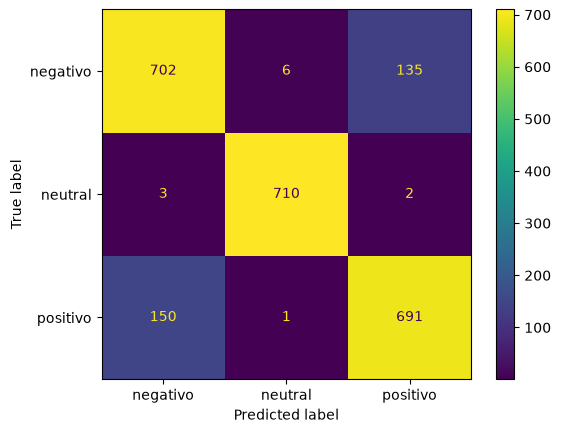

In [11]:
model_dt = LogisticRegression(max_iter=1000)
model_dt.fit(X_train_transformed, y_train)

y_pred = model_dt.predict(X_test_transformed)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

### Validación cruzada para hallar los mejores hiperparámetros


In [12]:
param_grid_logistic_l1 = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1"],
    "classifier__solver": ["saga"],
}

param_grid_logistic_l2 = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"],
}


def with_vectorizers(param_grid, vectorizer = None):
    """Expande el grid para probar cada vectorizador ('count' o 'tfidf') en el texto completo y en la última oración a la vez."""
    
    if vectorizer is not None:
        return [
            {
                **param_grid,
                "remove_first_sentence": [
                    "passthrough",
                    FunctionTransformer(remove_first_sentence),
                ],
                "vectorizers__text_vectorizer": [vectorizer_function(vectorizer)],
                "vectorizers__last_sentence_vectorizer": [vectorizer_function(vectorizer)],
            }
        ]
    return [
        {
            **param_grid,
            "remove_first_sentence": [
                "passthrough",
                FunctionTransformer(remove_first_sentence),
            ],
            "vectorizers__text_vectorizer": [vectorizer_function(name)],
            "vectorizers__last_sentence_vectorizer": [vectorizer_function(name)],
        }
        for name in VECTORIZERS
    ]


K_FOLDS = 5
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

In [13]:
pipeline_lr = Pipeline(
    [
        *build_preprocessor().steps,  # Los pasos se aplanan porque imblearn no permite Pipelines anidados
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)

grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid=with_vectorizers(param_grid_logistic_l1, vectorizer="tfidf")+with_vectorizers(param_grid_logistic_l2, vectorizer="tfidf"),
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,  # Necesario para las curvas de validación
)

grid_search_lr.fit(X_train, y_train)

/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, l

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1'], 'classifier__solver': ['saga'], 'remove_first_sentence': ['passthrough', FunctionTrans... 0x12f597560>)], ...}, {'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs'], 'remove_first_sentence': ['passthrough', FunctionTrans... 0x12f597560>)], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator

Accuracy of the best Logistic Regression model: 0.8791666666666667
Best parameters of the Logistic Regression model: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'saga', 'remove_first_sentence': 'passthrough', 'vectorizers__last_sentence_vectorizer': TfidfVectorizer(ngram_range=(1, 2), token_pattern=None,
                tokenizer=<function tokenizer_stemmer at 0x10727c540>), 'vectorizers__text_vectorizer': TfidfVectorizer(ngram_range=(1, 2), token_pattern=None,
                tokenizer=<function tokenizer_stemmer at 0x10727c540>)}
              precision    recall  f1-score   support

    negativo       0.84      0.82      0.83       843
     neutral       0.99      0.99      0.99       715
    positivo       0.83      0.84      0.83       842

    accuracy                           0.88      2400
   macro avg       0.88      0.88      0.88      2400
weighted avg       0.88      0.88      0.88      2400



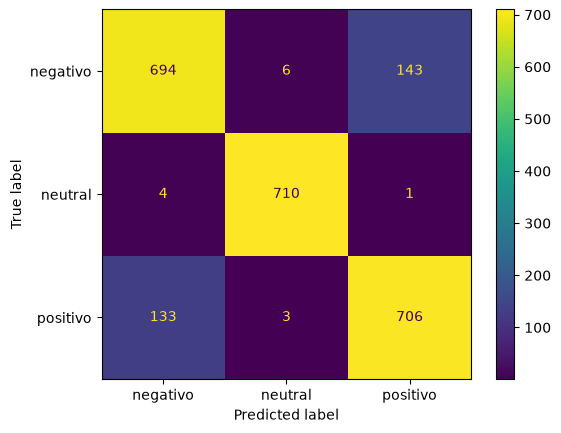

In [14]:
best_model_lr = grid_search_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy of the best Logistic Regression model: {accuracy_lr}")
print(
    f"Best parameters of the Logistic Regression model: {grid_search_lr.best_params_}"
)

print(classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_estimator(best_model_lr, X_test, y_test)
plt.show()

,first_sentence,vectorizer,penalty,C,mean_train_score,mean_test_score,std_test_score
0,Con primera oración,TfidfVectorizer,l1,100.0,1.0000,0.8816,0.0062
1,Sin primera oración,TfidfVectorizer,l2,10.0,0.9999,0.8794,0.0049


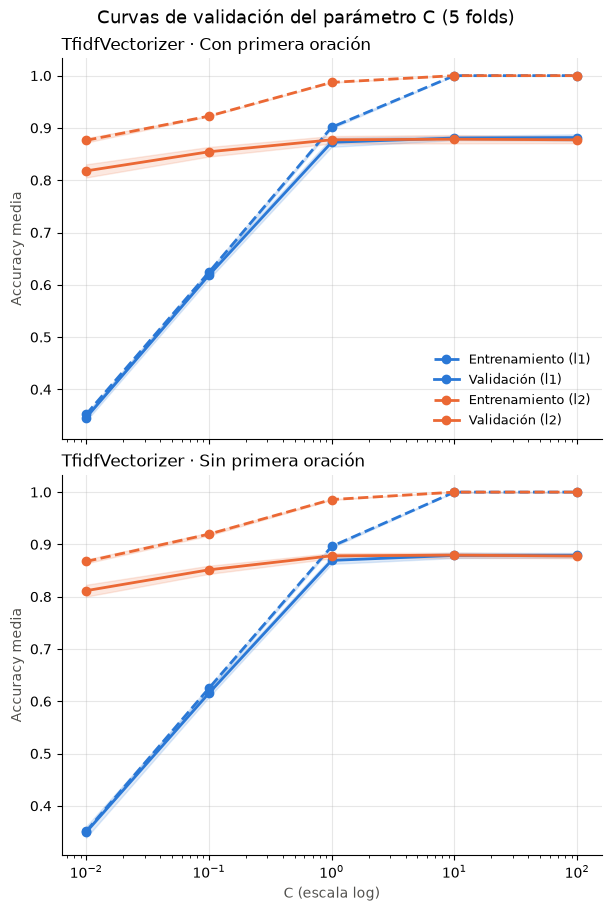

In [15]:
# Curvas de validación para C: accuracy media de entrenamiento y de validación dentro del KFold (± 1 desviación).
# Filas: se conserva o se elimina la primera oración. Columnas: vectorizador.
# Para cada penalización y valor de C se toma el solver con mejor accuracy de validación.
PENALTY_COLORS = {"l1": "#2a78d6", "l2": "#eb6834"}
SPLIT_STYLES = {"train": ("--", "Entrenamiento"), "test": ("-", "Validación")}

cv_results_lr = pd.DataFrame(grid_search_lr.cv_results_)
cv_results_lr["vectorizer"] = cv_results_lr["param_vectorizers__text_vectorizer"].map(
    lambda v: type(v).__name__
)
cv_results_lr["first_sentence"] = cv_results_lr["param_remove_first_sentence"].map(
    lambda step: (
        "Con primera oración" if step == "passthrough" else "Sin primera oración"
    )
)
cv_results_lr["penalty"] = cv_results_lr["param_classifier__penalty"]
cv_results_lr["C"] = cv_results_lr["param_classifier__C"].astype(float)

# Efecto de eliminar la primera oración: mejor configuración de cada opción
display(
    cv_results_lr.loc[
        cv_results_lr.groupby(["first_sentence", "vectorizer"])[
            "mean_test_score"
        ].idxmax(),
        [
            "first_sentence",
            "vectorizer",
            "penalty",
            "C",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
        ],
    ]
    .round(4)
    .reset_index(drop=True)
)

best_solver_idx = cv_results_lr.groupby(
    ["first_sentence", "vectorizer", "penalty", "C"]
)["mean_test_score"].idxmax()
curves = cv_results_lr.loc[best_solver_idx].sort_values("C")

first_sentence_options = curves["first_sentence"].unique()
vectorizers = curves["vectorizer"].unique()
fig, axes = plt.subplots(
    len(first_sentence_options),
    len(vectorizers),
    figsize=(6 * len(vectorizers), 4.5 * len(first_sentence_options)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)

for row, first_sentence in enumerate(first_sentence_options):
    for col, vectorizer in enumerate(vectorizers):
        ax = axes[row, col]
        subset = curves[
            (curves["first_sentence"] == first_sentence)
            & (curves["vectorizer"] == vectorizer)
        ]
        for penalty, results in subset.groupby("penalty"):
            color = PENALTY_COLORS[penalty]
            for split, (linestyle, split_label) in SPLIT_STYLES.items():
                mean = results[f"mean_{split}_score"]
                std = results[f"std_{split}_score"]
                ax.plot(
                    results["C"],
                    mean,
                    linestyle=linestyle,
                    marker="o",
                    markersize=6,
                    linewidth=2,
                    color=color,
                    label=f"{split_label} ({penalty})",
                )
                ax.fill_between(
                    results["C"], mean - std, mean + std, color=color, alpha=0.15
                )

        ax.set_xscale("log")
        ax.set_title(f"{vectorizer} · {first_sentence}", loc="left", fontsize=12)
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

for ax in axes[-1]:
    ax.set_xlabel("C (escala log)", color="#52514e")
for ax in axes[:, 0]:
    ax.set_ylabel("Accuracy media", color="#52514e")
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle(f"Curvas de validación del parámetro C ({K_FOLDS} folds)", fontsize=13)
plt.show()

,media,desviación,varianza,IC 95% inf,IC 95% sup
accuracy,0.879319,0.006601,0.000044,0.866250,0.891667
f1_macro,0.884721,0.006171,0.000038,0.872641,0.896668
f1_negativo,0.829363,0.009968,0.000099,0.809523,0.848236
f1_neutral,0.990314,0.002691,0.000007,0.984747,0.994955
f1_positivo,0.834484,0.009688,0.000094,0.815494,0.852672


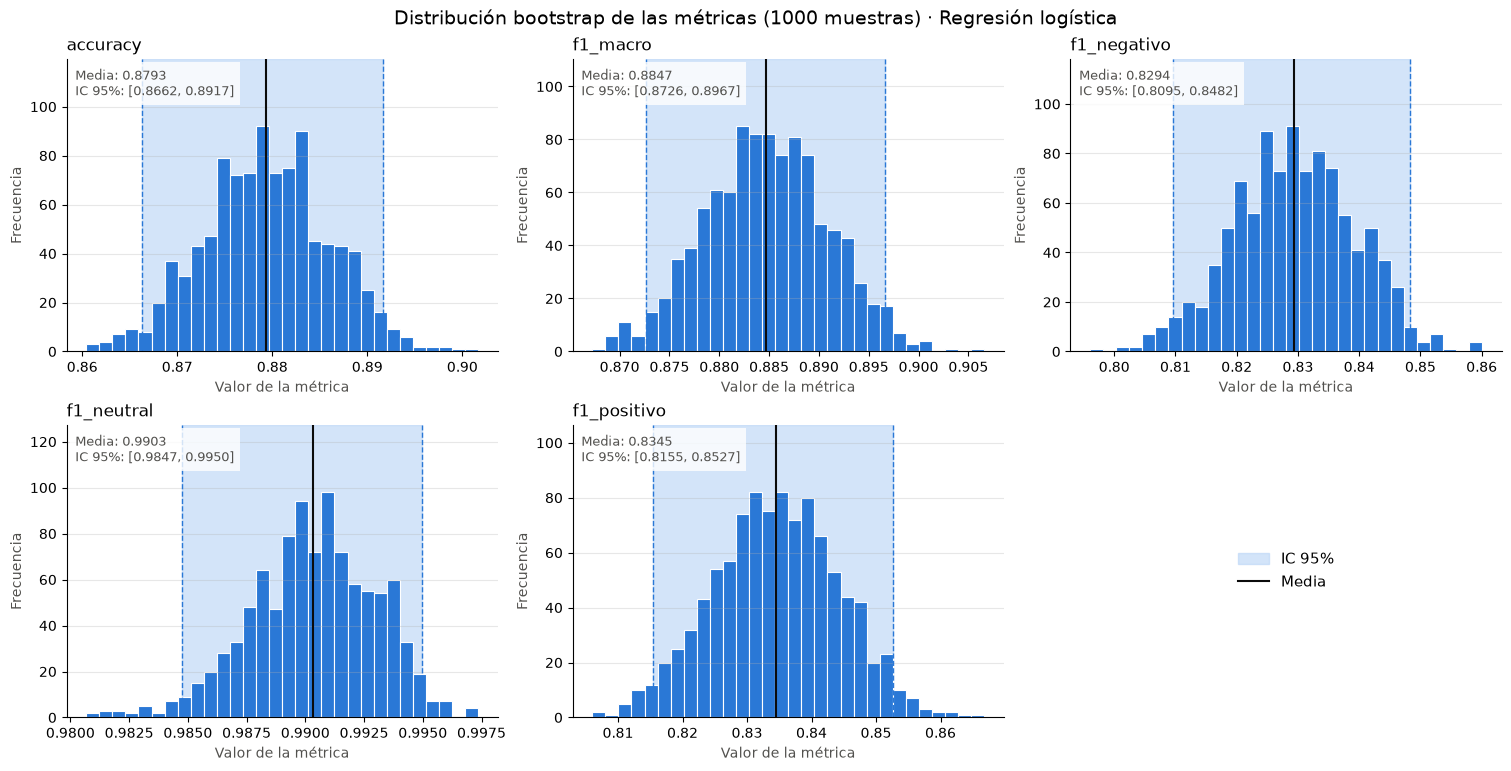

In [16]:
# Bootstrapping sobre los datos de validación: se remuestrean con reemplazo las predicciones de un modelo
# para estimar la varianza de las métricas sin reentrenar.
COLOR_HIST = "#2a78d6"
COLOR_IC = "#b7d3f6"
COLOR_TEXT = "#52514e"


def bootstrap_evaluation(
    y_true,
    y_pred,
    classes=None,
    n_bootstrap=1000,
    random_state=42,
    model_name=None,
    plot=True,
):
    """Estima la distribución de accuracy y F1 (macro y por clase) remuestreando las predicciones con reemplazo.

    Sirve para cualquier clasificador: solo necesita las etiquetas reales y las predicciones sobre validación.
    Retorna el DataFrame con los resultados de cada muestra y el resumen (media, desviación, varianza e IC 95%).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.unique(y_true) if classes is None else classes
    rng = np.random.RandomState(random_state)  # resample no acepta np.random.Generator

    results = []
    for _ in range(n_bootstrap):
        y_true_sample, y_pred_sample = resample(y_true, y_pred, random_state=rng)  # type: ignore[misc]
        f1_per_class = np.asarray(
            f1_score(y_true_sample, y_pred_sample, labels=classes, average=None)
        )
        results.append(
            {
                "accuracy": accuracy_score(y_true_sample, y_pred_sample),
                "f1_macro": f1_per_class.mean(),
                **{f"f1_{label}": score for label, score in zip(classes, f1_per_class)},
            }
        )

    results = pd.DataFrame(results)

    summary = pd.DataFrame(
        {
            "media": results.mean(),
            "desviación": results.std(),
            "varianza": results.var(),
            "IC 95% inf": results.quantile(0.025),
            "IC 95% sup": results.quantile(0.975),
        }
    )
    display(summary.round(6))

    if plot:
        plot_bootstrap(results, summary, model_name=model_name)

    return results, summary


def plot_bootstrap(results, summary, model_name=None):
    """Una gráfica por métrica: distribución bootstrap, media e intervalo de confianza del 95%."""
    metrics = results.columns
    n_cols = 3
    n_rows = int(np.ceil(len(metrics) / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), constrained_layout=True
    )
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics):
        values = results[metric]
        mean = summary.loc[metric, "media"]
        lower = summary.loc[metric, "IC 95% inf"]
        upper = summary.loc[metric, "IC 95% sup"]

        ax.axvspan(lower, upper, color=COLOR_IC, alpha=0.6, label="IC 95%")
        counts, _, _ = ax.hist(
            values, bins=30, color=COLOR_HIST, edgecolor="white", linewidth=0.8
        )
        ax.set_ylim(top=counts.max() * 1.3)  # Espacio para la anotación
        ax.axvline(mean, color="#0b0b0b", linewidth=1.5, label="Media")
        for bound in (lower, upper):
            ax.axvline(bound, color=COLOR_HIST, linestyle="--", linewidth=1)

        ax.set_title(metric, loc="left", fontsize=12)
        ax.text(
            0.02,
            0.97,
            f"Media: {mean:.4f}\nIC 95%: [{lower:.4f}, {upper:.4f}]",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            color=COLOR_TEXT,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8},
        )
        ax.set_xlabel("Valor de la métrica", color=COLOR_TEXT)
        ax.set_ylabel("Frecuencia", color=COLOR_TEXT)
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    for ax in axes[len(metrics) :]:
        ax.axis("off")
    if len(axes) > len(metrics):
        axes[-1].legend(handles, labels, loc="center", frameon=False, fontsize=11)
    else:
        fig.legend(handles, labels, loc="upper right", frameon=False)
    title = f"Distribución bootstrap de las métricas ({len(results)} muestras)"
    fig.suptitle(f"{title} · {model_name}" if model_name else title, fontsize=14)
    plt.show()


bootstrap_results_lr, bootstrap_summary_lr = bootstrap_evaluation(
    y_test, y_pred_lr, classes=best_model_lr.classes_, model_name="Regresión logística"
)

## Árbol de decision


Accuracy Decision Tree: 0.6045833333333334
              precision    recall  f1-score   support

    negativo       0.49      0.88      0.63       843
     neutral       0.83      0.80      0.81       715
    positivo       0.73      0.17      0.28       842

    accuracy                           0.60      2400
   macro avg       0.68      0.61      0.57      2400
weighted avg       0.67      0.60      0.56      2400



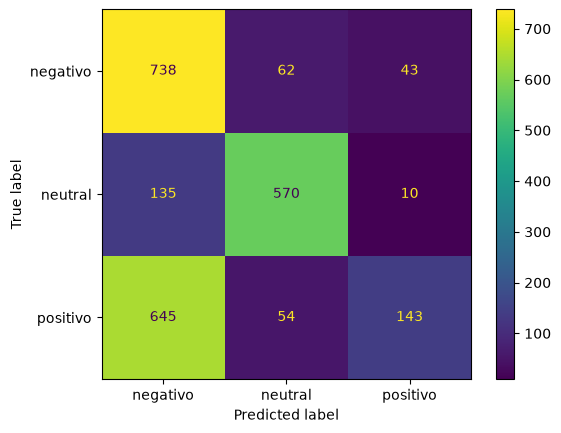

In [17]:
# Entrenamiento y evaluación del modelo Decision Tree con profundidad máxima de 10
model_dt = DecisionTreeClassifier(max_depth=10)
model_dt.fit(X_train_transformed, y_train)
y_pred_dt = model_dt.predict(X_test_transformed)

accuracy_decision_tree = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy Decision Tree: {accuracy_decision_tree}")
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.show()

In [ ]:
# Con texto vectorizado (disperso y de alta dimensión) el árbol necesita más profundidad,
# así que se amplía max_depth y se controla el sobreajuste con poda por complejidad (ccp_alpha).
# Se descartan splitter="random" y max_features="log2", que con miles de features apenas usan información.
param_grid_dt = {
    "max_depth": [10, 20, 40, 80, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt"],
    "ccp_alpha": [0.0, 1e-4, 5e-4, 1e-3],
}
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid_dt,
    scoring="accuracy",
    cv=kfold,
    n_jobs=-1,
    return_train_score=True,
)

grid_search_dt.fit(X_train_transformed, y_train)

Accuracy Decision Tree (Grid Search): 0.655
              precision    recall  f1-score   support

    negativo       0.57      0.60      0.59       843
     neutral       0.86      0.85      0.86       715
    positivo       0.56      0.55      0.56       842

    accuracy                           0.66      2400
   macro avg       0.67      0.66      0.67      2400
weighted avg       0.66      0.66      0.66      2400



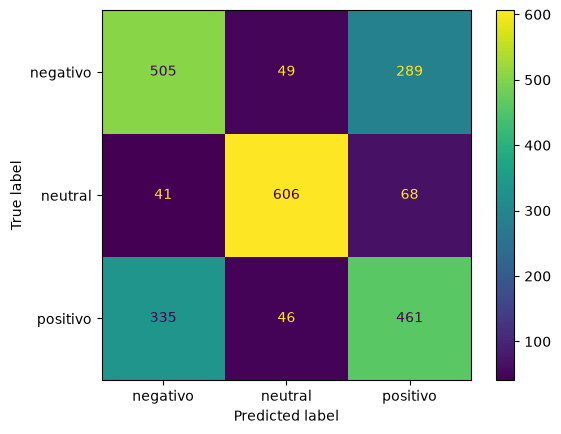

In [19]:
# Entrenamiento y evaluación del modelo Decision Tree con búsqueda en cuadrícula (Grid Search)
best_model_dt = grid_search_dt.best_estimator_
y_pred_grid_dt = best_model_dt.predict(X_test_transformed)

accuracy_grid_decision_tree = accuracy_score(y_test, y_pred_grid_dt)
print(f"Accuracy Decision Tree (Grid Search): {accuracy_grid_decision_tree}")
print(classification_report(y_test, y_pred_grid_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_grid_dt)
plt.show()

,media,desviación,varianza,IC 95% inf,IC 95% sup
accuracy,0.655085,0.009905,0.000098,0.635000,0.674167
f1_macro,0.665720,0.009240,0.000085,0.647720,0.683915
f1_negativo,0.585394,0.014177,0.000201,0.556731,0.611111
f1_neutral,0.856813,0.010295,0.000106,0.836124,0.876917
f1_positivo,0.554953,0.014670,0.000215,0.527622,0.582797


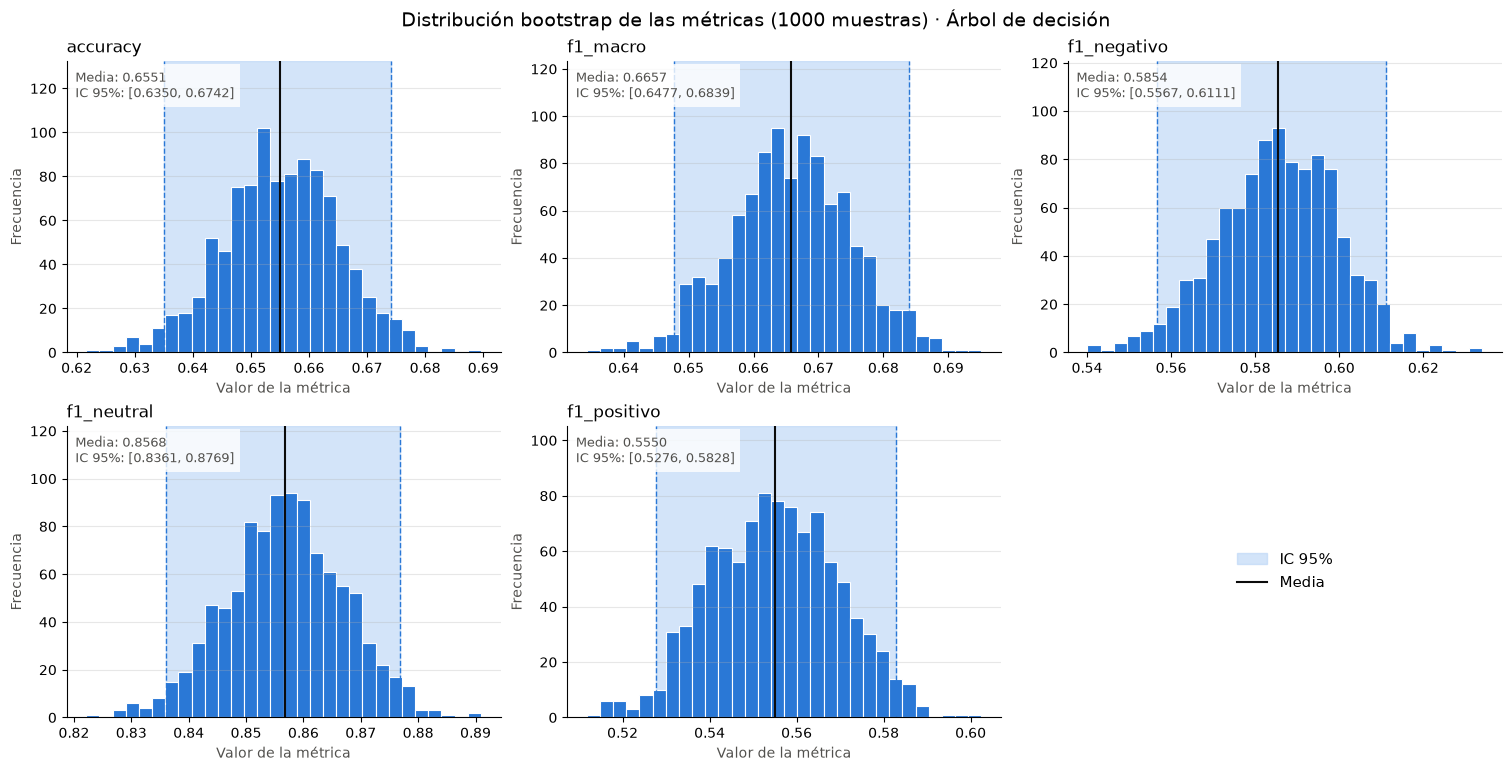

In [20]:
# Bootstrap evaluation of the best Decision Tree model
bootstrap_results_dt, bootstrap_summary_dt = bootstrap_evaluation(
    y_test,
    y_pred_grid_dt,
    classes=best_model_dt.classes_,
    model_name="Árbol de decisión",
)